In [2]:
import sys
sys.path.append('../datasets')
sys.path.append('../algorithms')
sys.path.append('../test')


import torch

import matplotlib.pyplot as plt
from pans import PANDataset
from alg1 import PANTVGradProj
from torchvision import transforms
from math import sqrt

In [3]:
# Define device (default is "cpu")
device = "cpu" 

    # Define dtype
dtype = torch.float64
crop_size = 128
    # Define random seed
seed = 42
torch.manual_seed(seed)

    # Define data path
data_path = '/home/ndiayem/Documents/spectral-spatial/data/harvard.zarr'

In [4]:
val_transform  =  transforms.Compose([ transforms.CenterCrop(crop_size)])
dataset =PANDataset(root_dir=data_path, split='train' ,transform=val_transform ,normalize=True,scale=2,sigma=0.1,device=device,size=crop_size)

In [5]:
idx = 17
X = dataset[idx]
X = X.unsqueeze(0)

In [6]:
X.shape
print(X)

tensor([[[[0.0127, 0.0127, 0.0125,  ..., 0.0138, 0.0127, 0.0105],
          [0.0130, 0.0110, 0.0133,  ..., 0.0110, 0.0125, 0.0089],
          [0.0099, 0.0120, 0.0133,  ..., 0.0115, 0.0117, 0.0092],
          ...,
          [0.0048, 0.0046, 0.0048,  ..., 0.0038, 0.0038, 0.0046],
          [0.0051, 0.0046, 0.0051,  ..., 0.0033, 0.0031, 0.0041],
          [0.0043, 0.0036, 0.0038,  ..., 0.0036, 0.0048, 0.0041]],

         [[0.0125, 0.0155, 0.0153,  ..., 0.0155, 0.0148, 0.0138],
          [0.0115, 0.0127, 0.0150,  ..., 0.0127, 0.0155, 0.0133],
          [0.0120, 0.0122, 0.0133,  ..., 0.0143, 0.0155, 0.0117],
          ...,
          [0.0059, 0.0054, 0.0059,  ..., 0.0036, 0.0033, 0.0041],
          [0.0041, 0.0059, 0.0054,  ..., 0.0041, 0.0036, 0.0043],
          [0.0066, 0.0061, 0.0069,  ..., 0.0036, 0.0036, 0.0043]],

         [[0.0206, 0.0206, 0.0219,  ..., 0.0222, 0.0265, 0.0201],
          [0.0217, 0.0217, 0.0227,  ..., 0.0206, 0.0224, 0.0194],
          [0.0235, 0.0212, 0.0214,  ..., 0

In [7]:
# Matrice de transformation
Y_H = dataset.simule_low_hsi(X)  
Y_M = dataset.get_panchromatic(X)
R = dataset.spectral(X)


In [8]:
print(Y_H)

tensor([[[[0.0088, 0.0096, 0.0102,  ..., 0.0082, 0.0082, 0.0084],
          [0.0107, 0.0120, 0.0128,  ..., 0.0092, 0.0093, 0.0097],
          [0.0110, 0.0129, 0.0137,  ..., 0.0078, 0.0081, 0.0091],
          ...,
          [0.0046, 0.0050, 0.0053,  ..., 0.0039, 0.0039, 0.0041],
          [0.0047, 0.0051, 0.0056,  ..., 0.0042, 0.0041, 0.0044],
          [0.0061, 0.0065, 0.0070,  ..., 0.0056, 0.0056, 0.0058]],

         [[0.0104, 0.0114, 0.0123,  ..., 0.0097, 0.0097, 0.0099],
          [0.0128, 0.0145, 0.0157,  ..., 0.0110, 0.0112, 0.0117],
          [0.0134, 0.0159, 0.0169,  ..., 0.0094, 0.0096, 0.0108],
          ...,
          [0.0053, 0.0058, 0.0059,  ..., 0.0039, 0.0041, 0.0045],
          [0.0054, 0.0059, 0.0062,  ..., 0.0043, 0.0044, 0.0047],
          [0.0070, 0.0077, 0.0082,  ..., 0.0063, 0.0063, 0.0065]],

         [[0.0156, 0.0173, 0.0190,  ..., 0.0136, 0.0139, 0.0145],
          [0.0197, 0.0225, 0.0244,  ..., 0.0159, 0.0162, 0.0174],
          [0.0207, 0.0249, 0.0264,  ..., 0

In [9]:
print(Y_M)

tensor([[[[0.2044, 0.2120, 0.2200,  ..., 0.1982, 0.1968, 0.1169],
          [0.2033, 0.2034, 0.2118,  ..., 0.1720, 0.1713, 0.1110],
          [0.2055, 0.2044, 0.2046,  ..., 0.1543, 0.1518, 0.1034],
          ...,
          [0.0372, 0.0404, 0.0451,  ..., 0.0235, 0.0241, 0.0232],
          [0.0336, 0.0356, 0.0471,  ..., 0.0233, 0.0229, 0.0233],
          [0.0426, 0.0378, 0.0435,  ..., 0.0236, 0.0226, 0.0236]]]])


In [10]:
Y_H.shape

torch.Size([1, 31, 64, 64])

In [11]:
Y_M.shape

torch.Size([1, 1, 128, 128])

In [12]:
# Calcul de l'adjoint
adjoint = dataset.simule_low_hsi_adjoint(Y_H)

# Test d'adjointitude
y = torch.randn_like(Y_H)
dot1 = torch.sum(y * dataset.simule_low_hsi(X))
dot2 = torch.sum(dataset.simule_low_hsi_adjoint(y) * X)
print(f"Test adjoint: {dot1.item():.6f} ≈ {dot2.item():.6f}")
print(f"Erreur adjoint: {abs(dot1 - dot2)/abs(dot1):.3e}")  # Doit être <1e-5

Test adjoint: -22.934940 ≈ -22.934933
Erreur adjoint: 3.327e-07


In [13]:
solver_gp = PANTVGradProj(
    A=dataset.simule_low_hsi,
    Aadj=dataset.simule_low_hsi_adjoint,
    max_iter=100,
    lmbda=1e-2,
    lmbda_m=2,
    tau=0.08,
    tol=1e-7,
    scale=dataset.scale,
    verbose=True,
    max_iter_gp=1000
)

In [14]:
U_gp, costs_gp = solver_gp(Y_H, Y_M,R)


Début de l'optimisation:
It    | Coût total   | Data H       | Data M       | TV           | ΔU          
--------------------------------------------------------------------------------
0     | 5.454e+02    | 4.549e+02    | 8.965e+01    | 3.667e+00    | 6.122e-02   
10    | 5.424e+02    | 4.524e+02    | 8.978e+01    | 1.098e+00    | 1.088e-02   
20    | 5.268e+02    | 4.391e+02    | 8.754e+01    | 9.281e-01    | 7.384e-03   
30    | 5.108e+02    | 4.254e+02    | 8.516e+01    | 8.593e-01    | 6.493e-03   
40    | 4.954e+02    | 4.123e+02    | 8.283e+01    | 8.078e-01    | 5.882e-03   
50    | 4.807e+02    | 3.999e+02    | 8.058e+01    | 7.663e-01    | 5.392e-03   
60    | 4.668e+02    | 3.882e+02    | 7.844e+01    | 7.304e-01    | 4.965e-03   
70    | 4.536e+02    | 3.770e+02    | 7.640e+01    | 7.001e-01    | 4.589e-03   
80    | 4.411e+02    | 3.664e+02    | 7.445e+01    | 6.738e-01    | 4.257e-03   
90    | 4.293e+02    | 3.565e+02    | 7.262e+01    | 6.495e-01    | 3.976e-03   
99

In [15]:
U_gp.shape

torch.Size([1, 31, 128, 128])

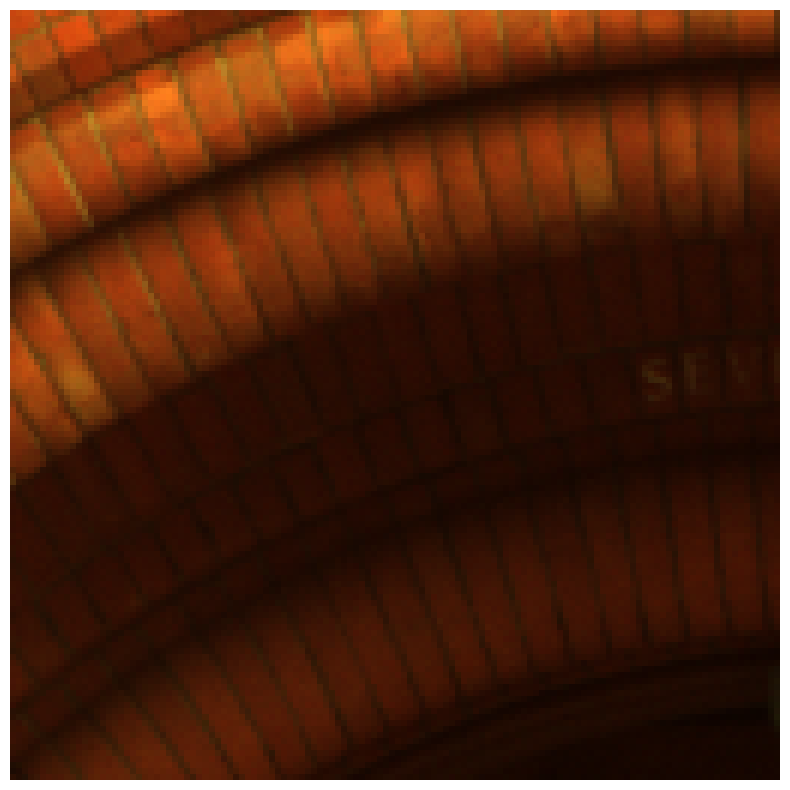

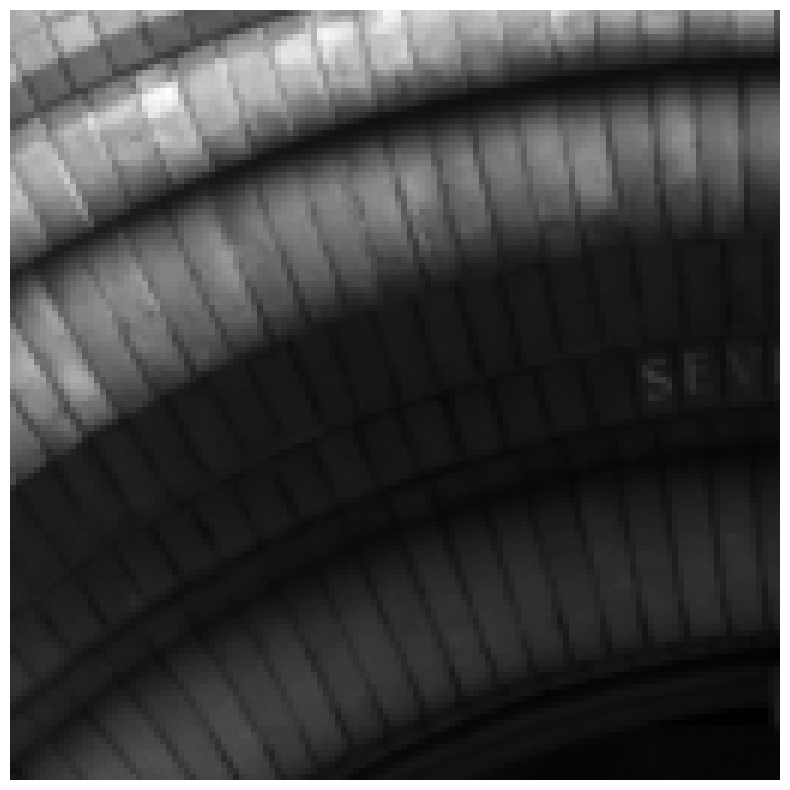

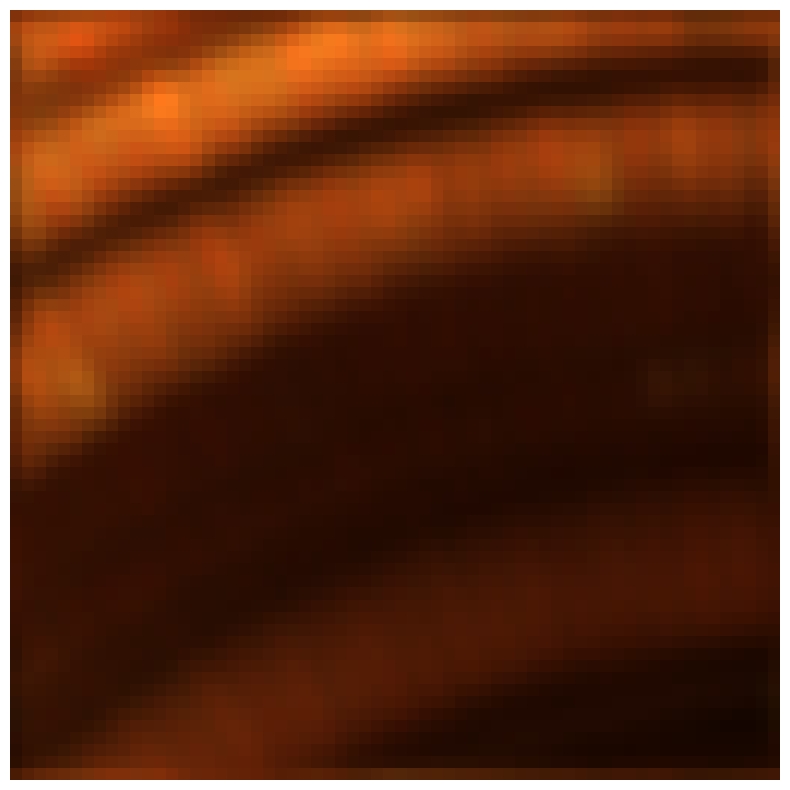

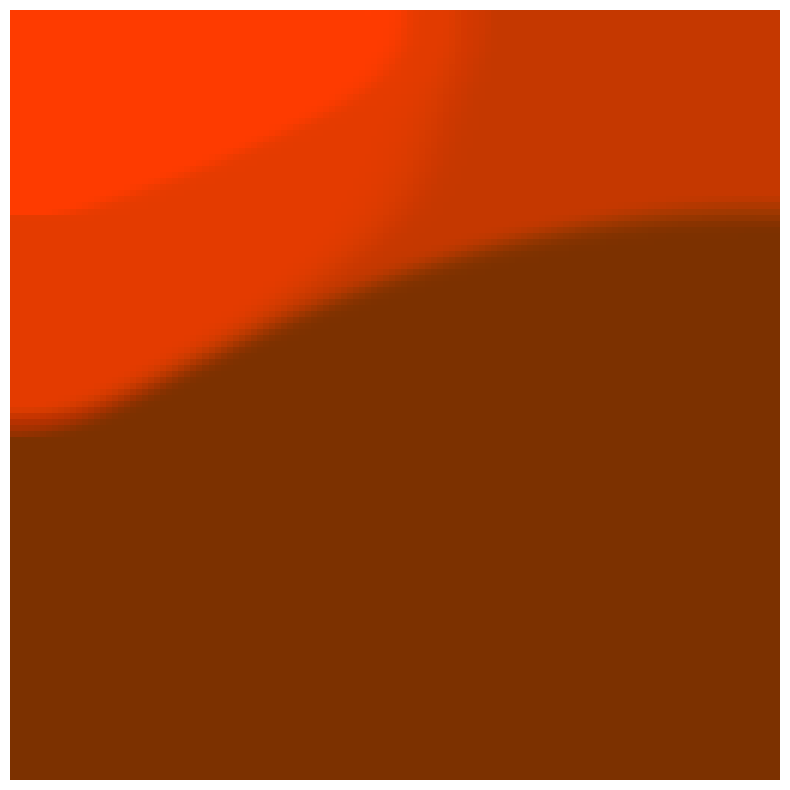

In [16]:
rgb = dataset.rgb_index
x_rgb = X[0, rgb,...].cpu().numpy().transpose(1, 2, 0)
x_rgb = (x_rgb - x_rgb.min())/(x_rgb.max() - x_rgb.min())

y_rgb = Y_H[0, rgb, ...].cpu().numpy().transpose(1, 2, 0)
y_rgb = (y_rgb - y_rgb.min())/(y_rgb.max() - y_rgb.min())

z_rgb = U_gp[0, rgb, ...].cpu().numpy().transpose(1, 2, 0)
z_rgb = (z_rgb - z_rgb.min())/(z_rgb.max() - z_rgb.min())

# plt.figure(figsize=(15, 5))
# plt.subplot(131)
plt.figure(figsize=(10,10))
plt.imshow(x_rgb)
# plt.title('RGB')
plt.axis('off')

# plt.subplot(132)
plt.figure(figsize=(10,10))
plt.imshow(Y_M[0, 0, ...].cpu().numpy(), cmap='gray')
# plt.title('Panchromatic')
plt.axis('off')

# plt.subplot(133)
plt.figure(figsize=(10,10))
plt.imshow(y_rgb)
# plt.title('Noisy RGB')
plt.axis('off')

# plt.subplot(133)
plt.figure(figsize=(10,10))
plt.imshow(z_rgb)
# plt.title('Noisy RGB')=4
plt.axis('off')

plt.show()

Dimensions vérifiées: iterations (100,), cout_total 100


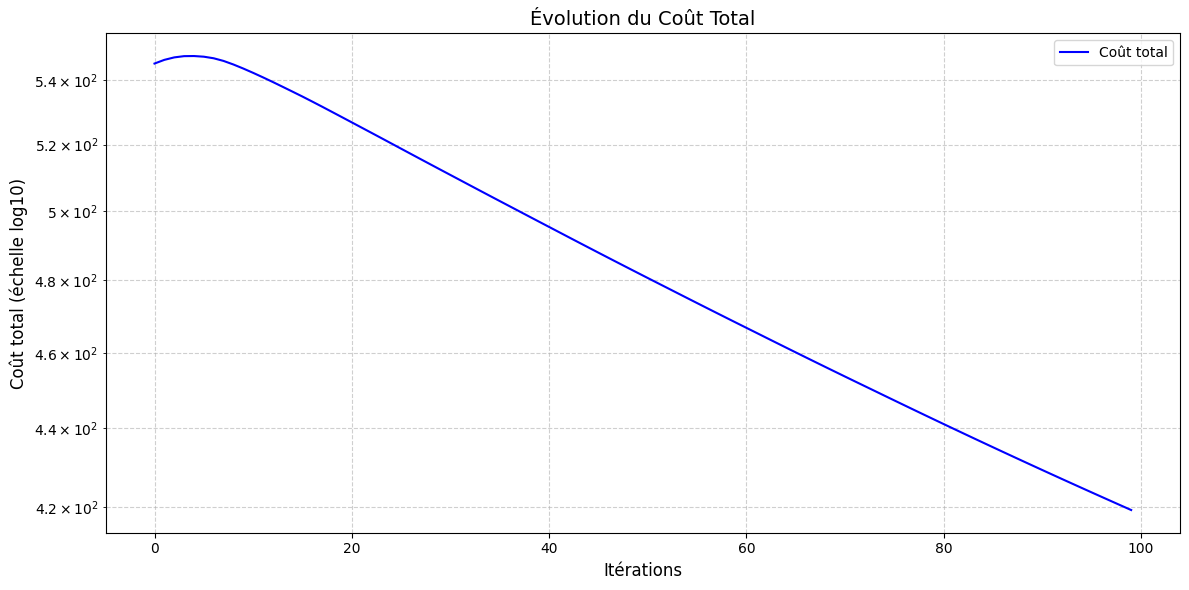

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Données d'exemple (à adapter avec vos données réelles)
cout_total = costs_gp

# Création du vecteur d'itérations de même longueur que cout_total
iterations = np.arange(0, len(cout_total))  # Pas de 10 entre les mesures

# Vérification des dimensions
print(f"Dimensions vérifiées: iterations {iterations.shape}, cout_total {len(cout_total)}")

# Création du graphique
plt.figure(figsize=(12, 6))
plt.semilogy(iterations, cout_total, 'b-', linewidth=1.5, label='Coût total')

# Personnalisation
plt.xlabel('Itérations', fontsize=12)
plt.ylabel('Coût total (échelle log10)', fontsize=12)
plt.title('Évolution du Coût Total', fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.6)

# Affichage
plt.legend()
plt.tight_layout()
plt.show()